### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding

In [4]:
from src.paths.paths import ALL_CELLS_PATH 

In [5]:
adata = sc.read_h5ad("../../../data/HGSOC/ALL_CELLS/all_cells_1p.h5ad")

In [6]:
# Get unnormalized gene expression reads
# REQUIREMENT: CellUntangler requires gene-expression counts
adata = adata.raw.to_adata()

### Sanity-Checking the Data

In [7]:
np.min(adata.X.todense())

0.0

In [8]:
np.max(adata.X.todense()) == 46163.0

True

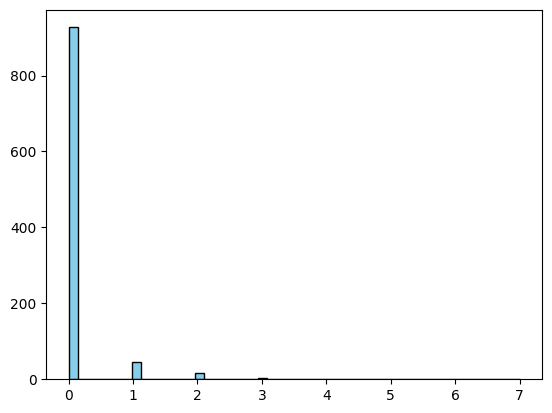

In [9]:
sample = np.random.choice(np.asarray(adata.X.todense()).flatten(), size=1000, replace=False)

# Plot histogram
plt.hist(sample, bins=50, color='skyblue', edgecolor='black')
plt.show()

### Pre-processing

In [10]:
adata.var["gene_symbols"] = adata.var["feature_name"]

In [11]:
cell_cycle_genes_path = "../../../genes/celluntangler_human_cell_cycle_genes.tsv"
interferon_genes_path = "../../../genes/HGSOC/multi_signal/llm_11_2025/human_interferon_genes.tsv" 
dissociation_genes_path = "../../../genes/HGSOC/multi_signal/llm_11_2025/human_cell_dissociation_genes.tsv" 

cell_cycle_genes = pd.read_csv(cell_cycle_genes_path, header = None, sep="\t")
interferon_genes = pd.read_csv(interferon_genes_path, header = None, sep="\t") # PROGRESS!!!
dissociation_genes = pd.read_csv(dissociation_genes_path, header = None, sep = "\t")

In [12]:
## Brief Analysis of Number of Relevant Genes Found 

In [13]:
cell_cycle_genes_set = set(cell_cycle_genes.iloc[:,0])
interferon_genes_set = set(interferon_genes.iloc[:,0]) 
dissociation_genes_set = set(dissociation_genes.iloc[:,0])

In [14]:
"""
gene_sets = { "cell cycle genes": cell_cycle_genes_set, 
              "interferon genes": interferon_genes_set,
              "dissociation_genes": dissociation_genes_set }
for name0, genes0 in gene_sets.items():  
    for name1, genes1 in gene_sets.items() : 
        if (name0 != name1): 
            print(f"Intersection between: {name0}, {name1}") 
            print(genes0.intersection(genes1))
"""

'\ngene_sets = { "cell cycle genes": cell_cycle_genes_set, \n              "interferon genes": interferon_genes_set,\n              "dissociation_genes": dissociation_genes_set }\nfor name0, genes0 in gene_sets.items():  \n    for name1, genes1 in gene_sets.items() : \n        if (name0 != name1): \n            print(f"Intersection between: {name0}, {name1}") \n            print(genes0.intersection(genes1))\n'

In [15]:
contained_genes_cc = adata.var["gene_symbols"].isin(cell_cycle_genes[0])
contained_genes_interferon = adata.var["gene_symbols"].isin(interferon_genes[0])
contained_genes_dissociation = adata.var["gene_symbols"].isin(dissociation_genes[0])
# print(f"Number of cell cycle genes present in adata: {np.sum(contained_genes_cc)}")
# print(f"Number of interferon genes present in adata: {np.sum(contained_genes_interferon)}")
# print(f"Number of cell dissociation genes present in adata: {np.sum(contained_genes_dissociation)}")

In [16]:
# Order Genes in adata such that genes appear in following order: cell cycle genes, interferon genes, dissociation genes
cc_indices = np.where(contained_genes_cc)[0]
interferon_indices = np.where(contained_genes_interferon)[0]
dissociation_indices = np.where(contained_genes_dissociation)[0]

all_known_indices = np.hstack((cc_indices, interferon_indices, dissociation_indices))
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((cc_indices, interferon_indices, dissociation_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [17]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_71411/1082852305.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!


### Pre-processing x2 - Calculating Gene-Enrichment Scores 

In [18]:
from anndata.utils import make_index_unique

# 1. Get the gene symbols and convert to a standard pandas Index
temp_index = pd.Index(adata.var['gene_symbols'].astype(str))

# 2. Use the anndata utility to make the index unique (appends -1, -2, etc. to duplicates)
adata.var_names = make_index_unique(temp_index)
adata.var_names.name = None
adata.raw = adata ### FIX!!!

In [19]:
sc.tl.score_genes(
    adata,
    gene_list=interferon_genes_set,
    score_name="interferon_score"
)


sc.tl.score_genes(
    adata,
    gene_list=dissociation_genes_set,
    score_name="dissociation_score"
)

### Model Configuration

In [20]:
model_name = "r2, e2, e2, e10"

In [21]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 100 # TODO - change to 500 once verified working 
config.epochs = 100 

In [22]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [23]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [24]:
# adata.obs["batch"].unique()

In [25]:
batch = adata.obs.batch.cat.codes.values 
batch = batch[:,None]
batch = batch.astype(np.int64) 

In [26]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [ len(np.unique(batch)) ]

In [27]:
batch_counts = np.bincount(batch[:,0])
batch_counts = batch_counts[1:]

In [28]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

In [29]:
# y holds the batch vector for the dataset
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 31815
dataset.in_dim = 31815
Dataset seed: 68715


In [30]:
# Creating (Disjoint) Masks
mask_cyc = np.zeros(adata.n_vars)
mask_cyc[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 1
mask_interferon = np.zeros(adata.n_vars)
mask_interferon[adata.var["gene_symbols"].isin(interferon_genes[0])] = 1
mask_dissociation = np.zeros(adata.n_vars) 
mask_dissociation[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(cell_cycle_genes[0])] = 0 
mask_all[adata.var["gene_symbols"].isin(interferon_genes[0])] = 0 
mask_all[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 0 

mask = torch.tensor([mask_cyc, mask_interferon, mask_dissociation, mask_all])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_71411/3504034827.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_cyc, mask_interferon, mask_dissociation, mask_all])


### Configure Save Paths

In [31]:
epoch_embeddings_save_path = ALL_CELLS_PATH
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

In [32]:
# TODO - add functionality for plotting a log-likelihood plot every 50 epochs or so

In [33]:
"""
import umap
M = np.asarray(x)  # ensure ndarray (important if it's a numpy.matrix)

n_samples = 400
idx = np.random.choice(M.shape[0], size=n_samples, replace=False)
M_sub = M[idx]
M_sub.shape == (400, 31815)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding = reducer.fit_transform(M_sub)

plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=15,
    alpha=0.7
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of 400 Randomly Sampled Rows")
plt.show()
"""

'\nimport umap\nM = np.asarray(x)  # ensure ndarray (important if it\'s a numpy.matrix)\n\nn_samples = 400\nidx = np.random.choice(M.shape[0], size=n_samples, replace=False)\nM_sub = M[idx]\nM_sub.shape == (400, 31815)\n\nreducer = umap.UMAP(\n    n_neighbors=15,\n    min_dist=0.1,\n    n_components=2,\n    random_state=42\n)\n\nembedding = reducer.fit_transform(M_sub)\n\nplt.figure(figsize=(6, 6))\nplt.scatter(\n    embedding[:, 0],\n    embedding[:, 1],\n    s=15,\n    alpha=0.7\n)\nplt.xlabel("UMAP-1")\nplt.ylabel("UMAP-2")\nplt.title("UMAP of 400 Randomly Sampled Rows")\nplt.show()\n'

### Model Creation

In [34]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [35]:
torch.set_default_dtype(torch.float64)

In [36]:
component_subspaces = {0 :[0], 1: [0,1], 2:[0,1,2], 3: [0,1,2,3]}
component_no_grads = {1: [0], 2: [0,1], 3: [0,1,2]}
# Q: When would one want to zero out the batch vector while decoding? 
component_batch =  {0: True, 1: True, 2: True, 3: True }

In [37]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config,
              component_subspaces=component_subspaces,
              component_no_grads=component_no_grads,
              component_batch=component_batch).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
RotatedHyperbolicComponent(R^3)


In [38]:
config

activation: gelu
batch_invariant: true
batch_size: 128
device: !!python/object/apply:torch.device
- cpu
end: 1.0
end_epoch: 1
end_z2_no_grad: 500
epochs: 100
eps: 0.001
fixed_curvature: true
gain: 1.0
h_dim: 32
init: custom
learning_rate: 0.001
max_epochs: 100
model_name: r2, e2, e2, e10
momentum: 0.99
n_batch:
- 41
scalar_parametrization: false
seed: 68715
start: 1.0
start_z2_no_grad: 0
use_adamw: true
use_batch_norm: false
use_z1_batch: true
use_z2_batch: true
use_z2_no_grad: false
weight_decay: null

### Training

In [ ]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)

trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

### Saving Embeddings

In [50]:
embeddings_save_path = epoch_embeddings_save_path

In [51]:
a = trainer.model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'), a[4].detach().to(torch.device("cpu")).numpy())

NameError: name 'trainer' is not defined

### Analysis

In [52]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [53]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

r2 3
e10 10
e10 10
e10 10


#### Visualization of Component 1 (R2)

##### Visualization fo Cell Cycle Signals

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/CellUntangler/src/visualization/visualization_functions.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


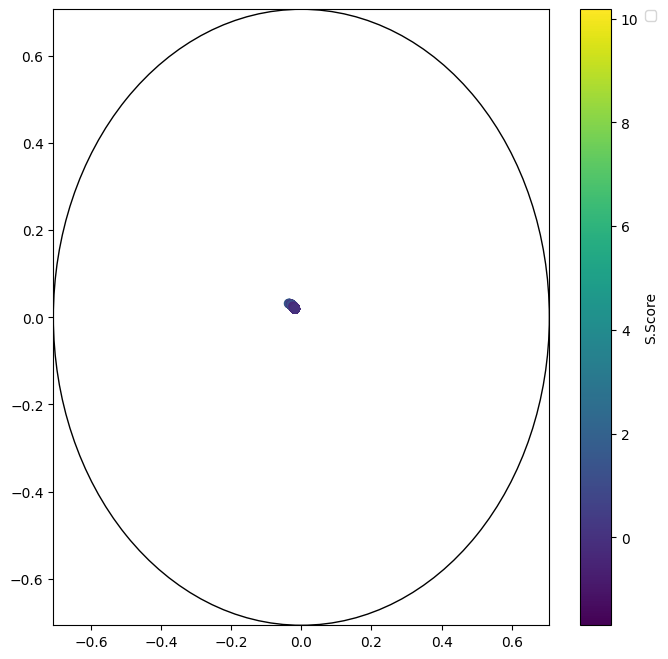

In [51]:
embeddings_key = "component1_r2"
desired_obs = 'S.Score'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label="S.Score",
                      bbox_to_anchor=legend_coordinates)

Text(0.5, 1.0, 'S Score Distribution')

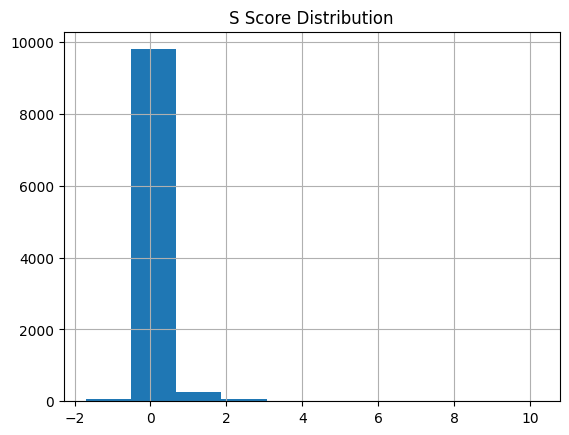

In [60]:
ax = adata.obs["S.Score"].hist()
ax.set_title("S Score Distribution")

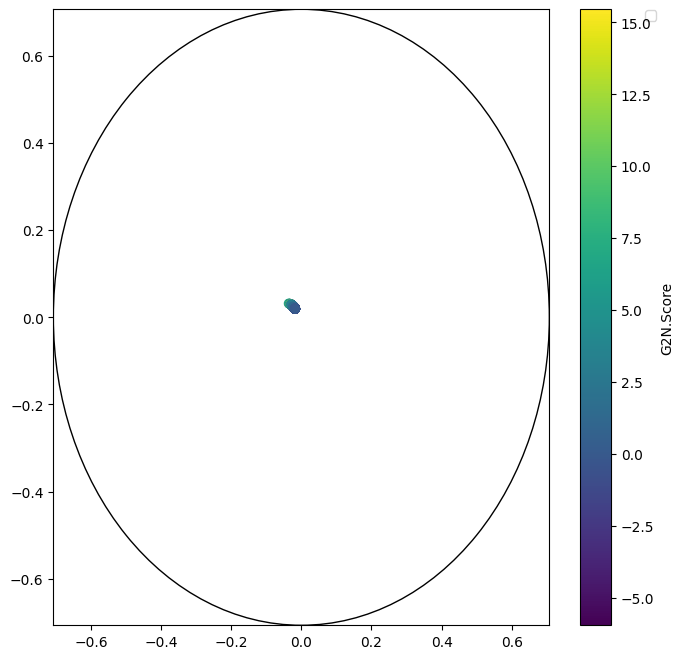

In [246]:
embeddings_key = "component1_r2"
desired_obs = 'G2M.Score'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label="G2N.Score",
                      bbox_to_anchor=legend_coordinates)

##### Visualization of Cell Type Signals

In [249]:
embeddings_key = "component1_r2"
desired_obs = 'Myofibroblast.module'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label="Myofibroblast.module",
                      bbox_to_anchor=legend_coordinates)

KeyError: 'Myofibroblast.module'

In [73]:
adata.obsm[embeddings_key]

array([[ 0.9481343 ,  0.54542878, -0.31853747],
       [ 0.72780428,  0.08008249, -0.15259711],
       [ 0.85418858, -0.21721714, -0.42714736],
       ...,
       [ 3.80574553, -3.40690923, -1.54164475],
       [ 0.97652252, -0.55860972,  0.37623321],
       [ 1.35101539,  1.11012083, -0.30475292]], shape=(10505, 3))

#### Visualization of Component 2 (E10)

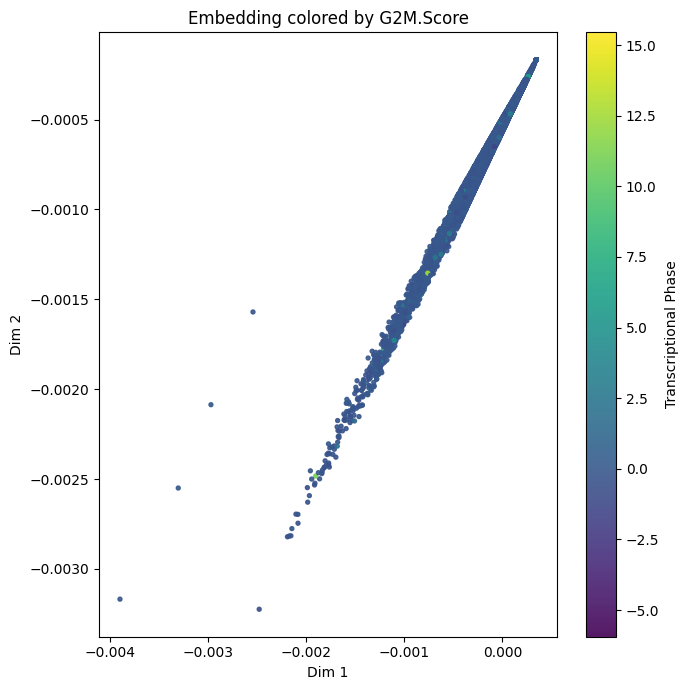

In [247]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

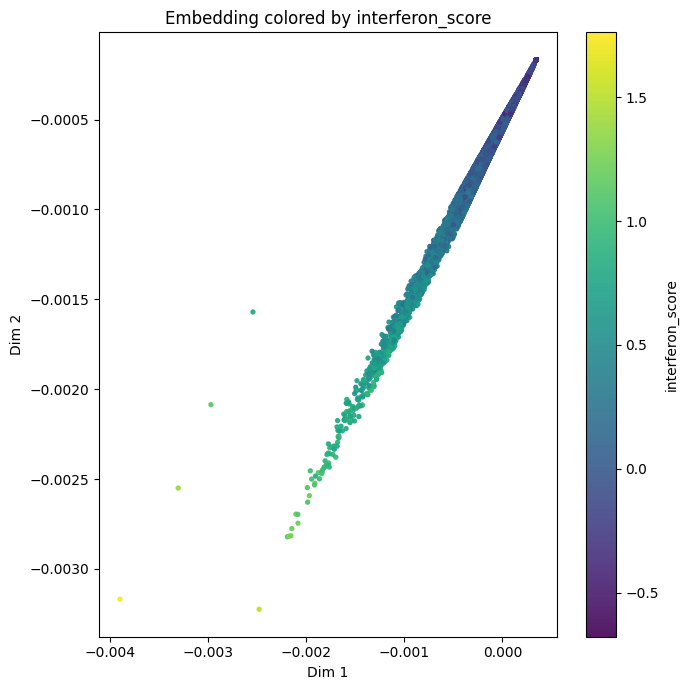

In [248]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

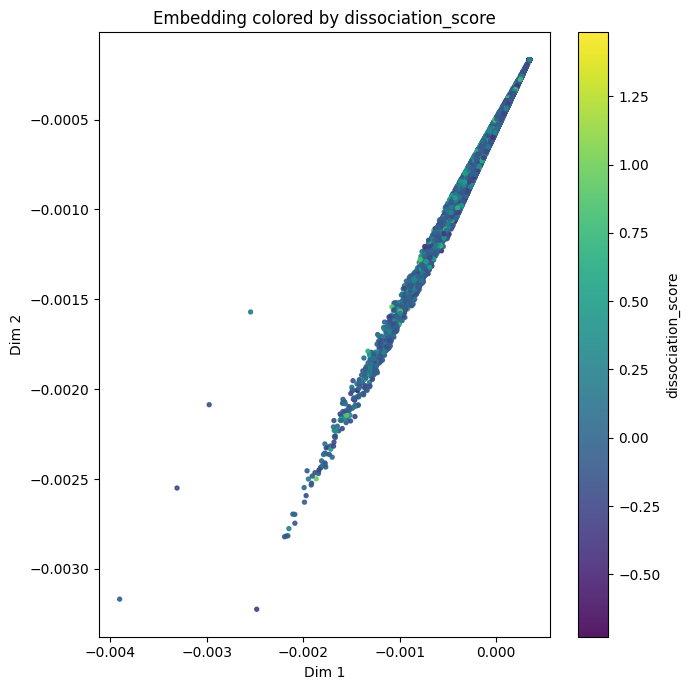

In [253]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

In [47]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'HALLMARK_INTERFERON_ALPHA_RESPONSE'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="HALLMARK_INTEFERON_ALPHA_RESPONSE",
    bbox_to_anchor=(1.23, 1.01)
)

KeyError: 'HALLMARK_INTERFERON_ALPHA_RESPONSE'

In [63]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'HALLMARK_INTERFERON_GAMMA_RESPONSE'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

KeyError: 'HALLMARK_INTERFERON_GAMMA_RESPONSE'

#### Visualization of Component 3 (E10)

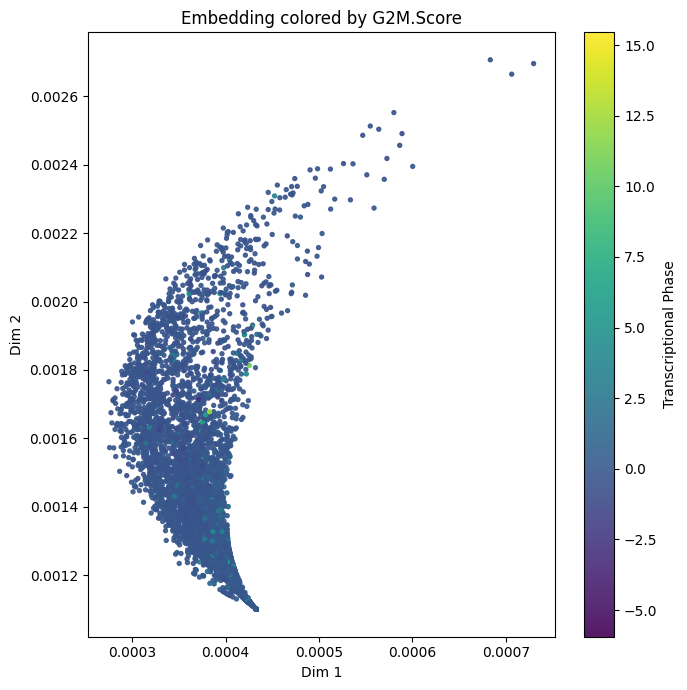

In [250]:
##### TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

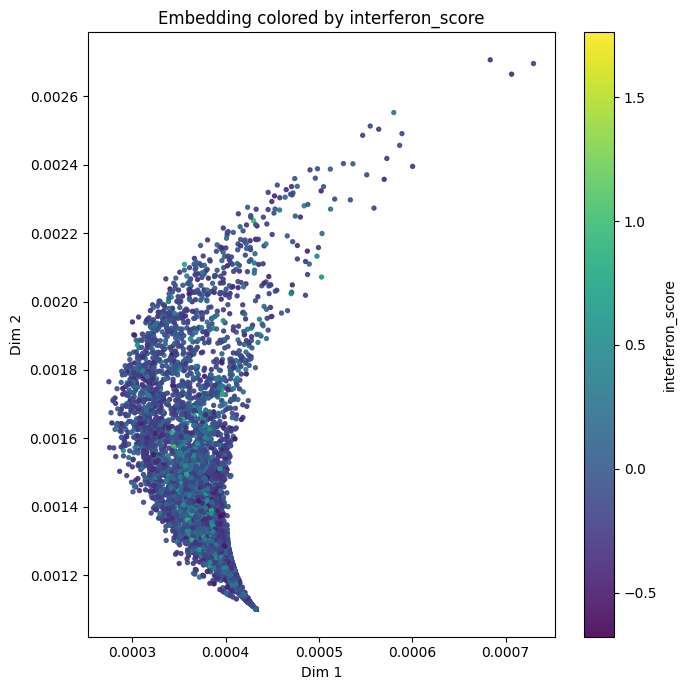

In [252]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

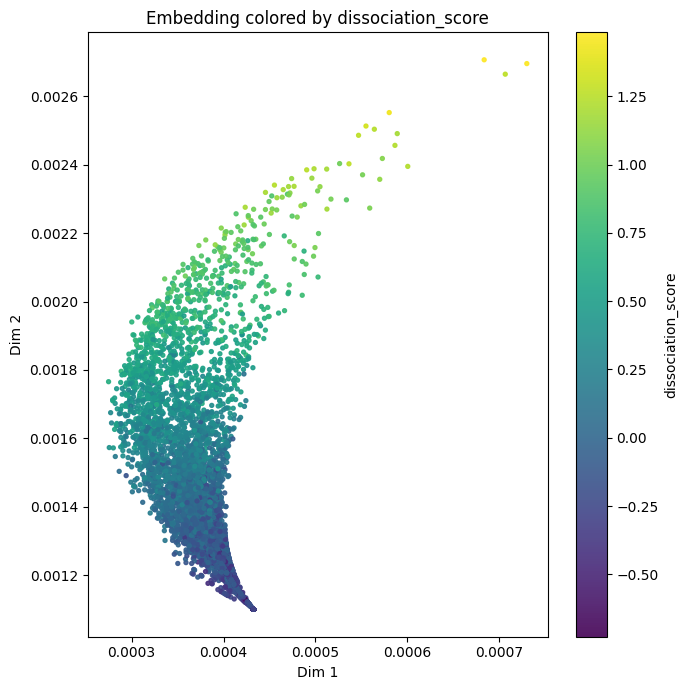

In [251]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

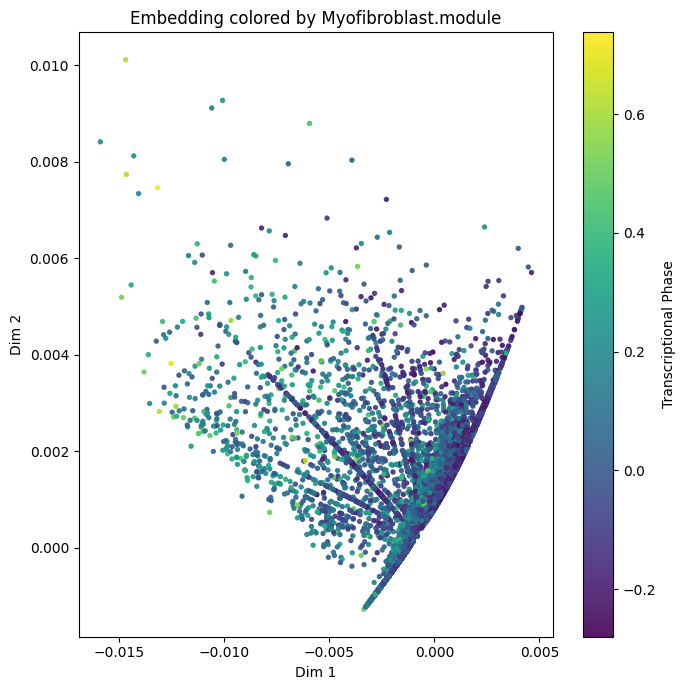

In [76]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component3_e10"
desired_obs = 'Myofibroblast.module'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

#### Visualization of Component 4 (E10)

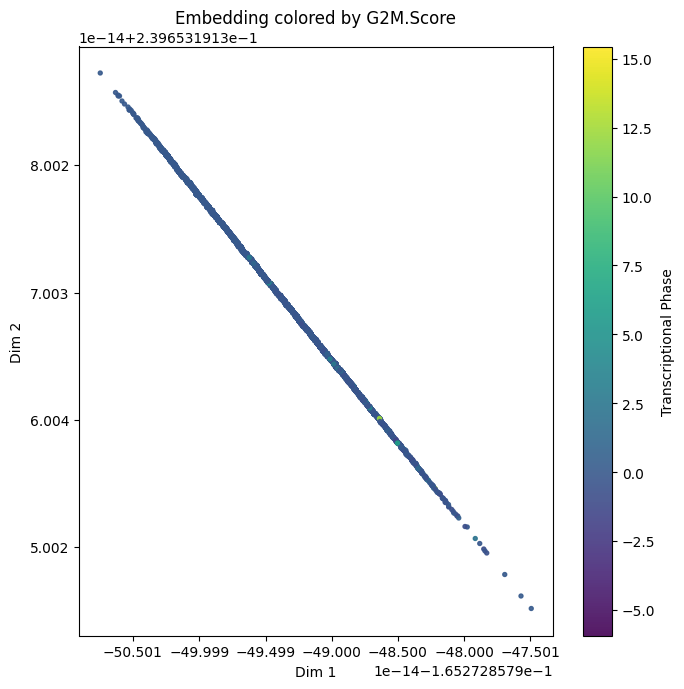

In [64]:
# TODO - add custom UMAP code that doesn't hang! 
# Visualize UMAP using cell cycle ground truth, cell type ground truth, other labels, .... 
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component4_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
    bbox_to_anchor=(1.23, 1.01)
)

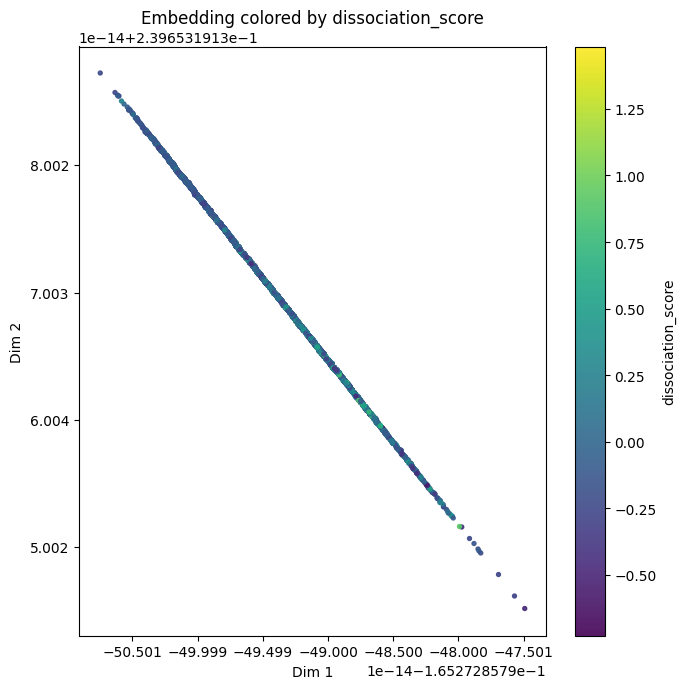

In [63]:
embeddings_key = "component4_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

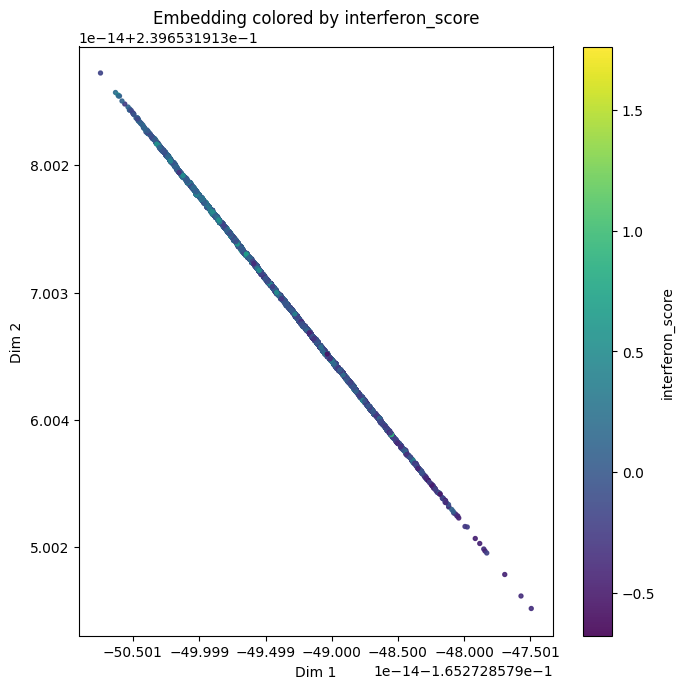

In [61]:
embeddings_key = "component4_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

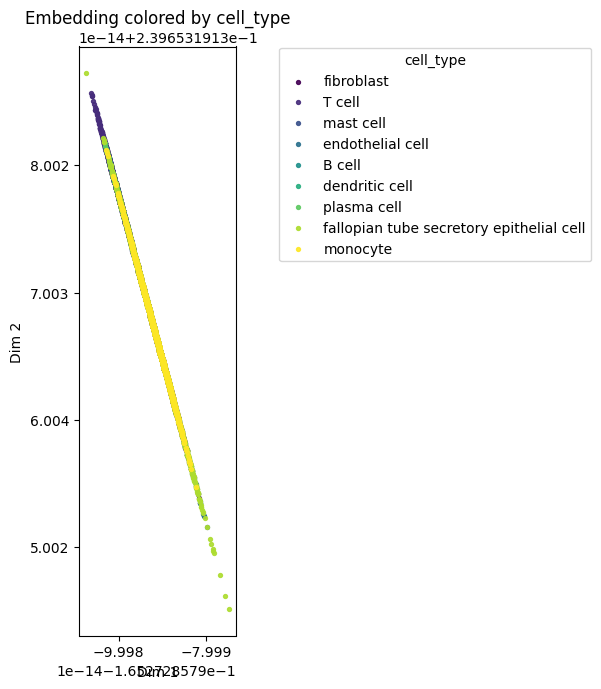

In [62]:
embeddings_key = "component4_e10"
desired_obs = 'cell_type'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Myofibroblast.module",
    bbox_to_anchor=(1.23, 1.01)
)

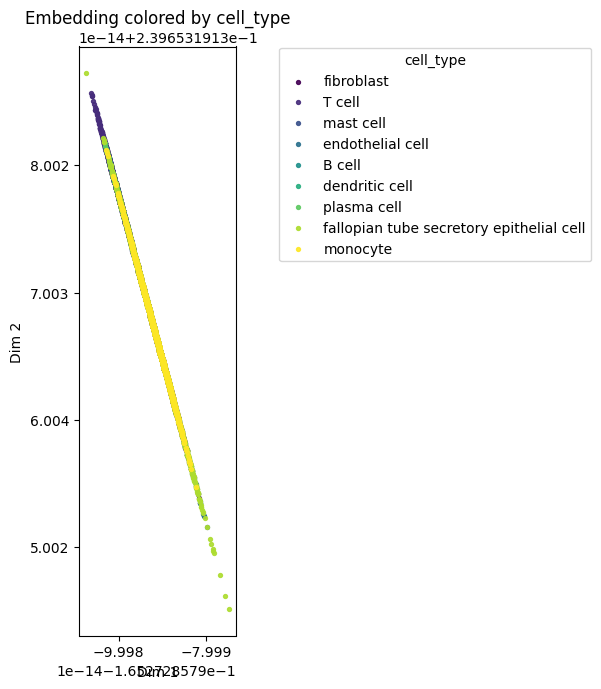

In [65]:
embeddings_key = "component4_e10"
desired_obs = 'cell_type'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01)
)

#### Pairwise Plots - 1 Sanity Check Against Sarah's Work

In [54]:
for cell_type in adata.obs["cell_type"].unique(): 
    print(cell_type)

T cell
fallopian tube secretory epithelial cell
fibroblast
monocyte
plasma cell
dendritic cell
endothelial cell
B cell
mast cell


In [55]:
mask_tcell = adata.obs["cell_type"] == "T cell"
mask_fallopian = adata.obs["cell_type"] == "fallopian tube secretory epithelial cell"
mask_fibroblast = adata.obs["cell_type"] == "fibroblast"
mask_monocyte = adata.obs["cell_type"] == "monocyte"
mask_plasma = adata.obs["cell_type"] == "plasma cell"
mask_dendritic = adata.obs["cell_type"] == "dendritic cell"
mask_endothelial = adata.obs["cell_type"] == "endothelial cell"
mask_bcell = adata.obs["cell_type"] == "B cell"
mask_mast = adata.obs["cell_type"] == "mast cell"

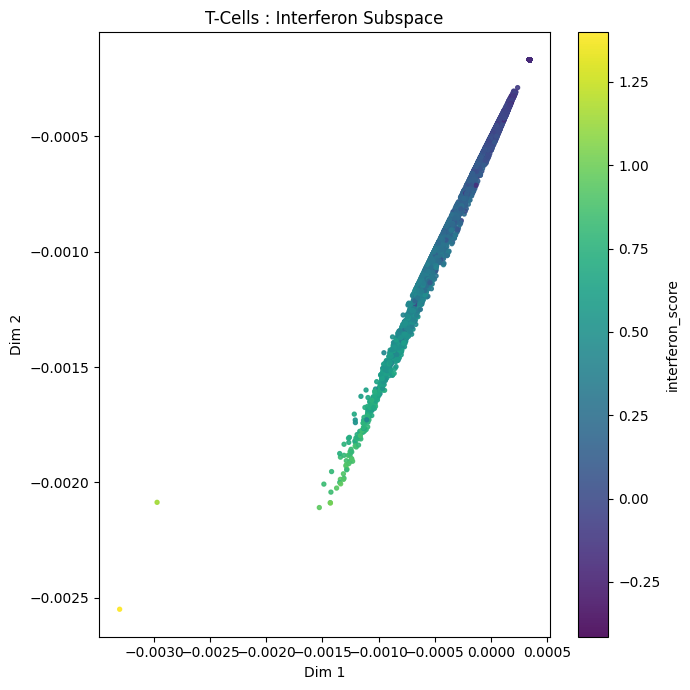

In [56]:
# T-cells
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Interferon Subspace" 
)

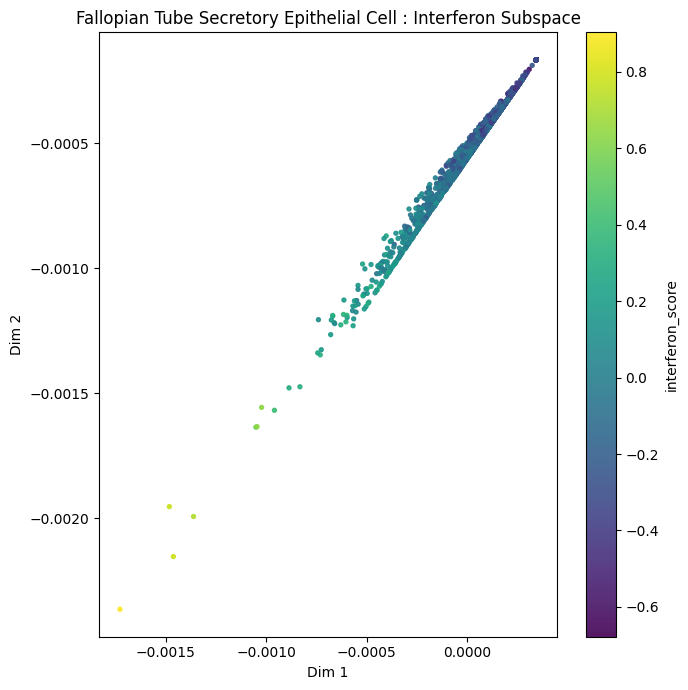

In [57]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Interferon Subspace" 
)

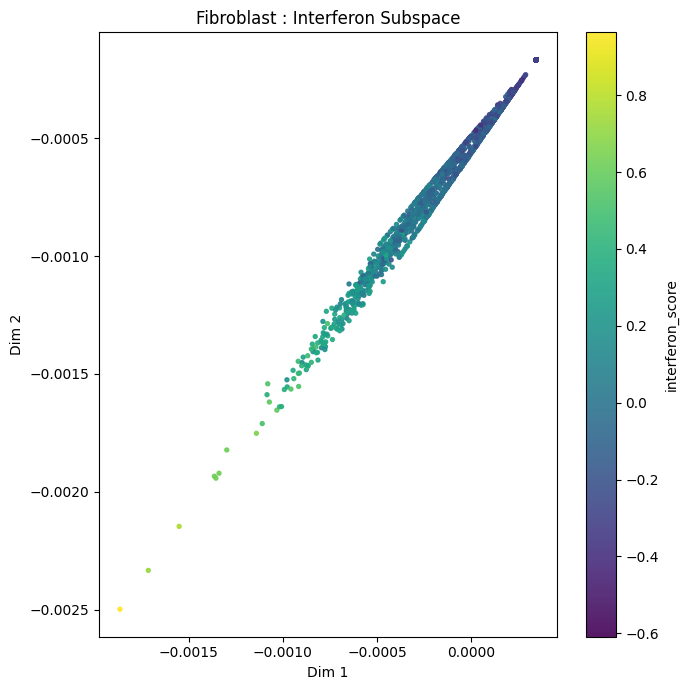

In [58]:
# Fibroblast 
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Interferon Subspace" 
)

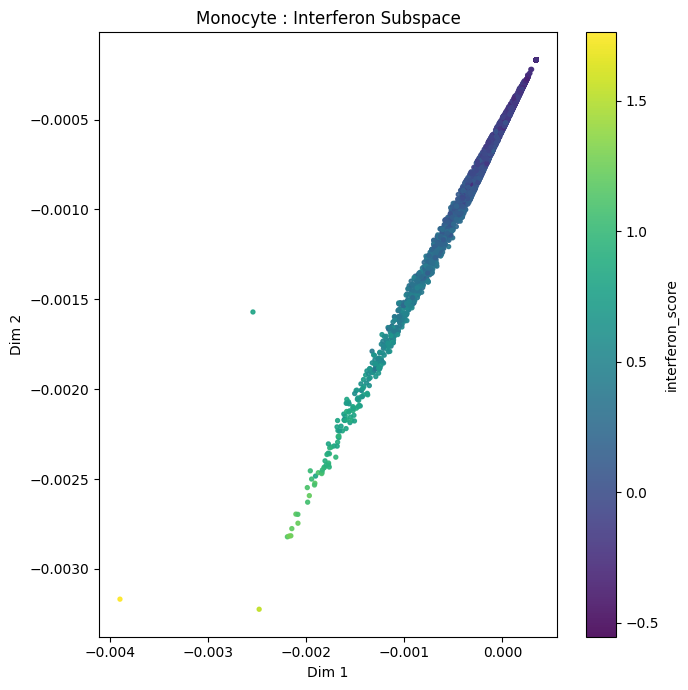

In [59]:
# Monocyte
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Interferon Subspace" 
)

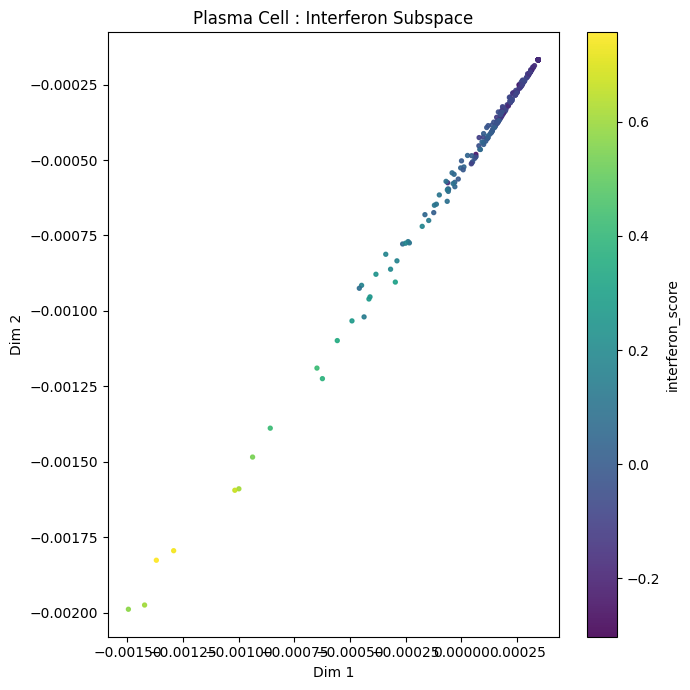

In [60]:
# Plasma cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Interferon Subspace" 
)

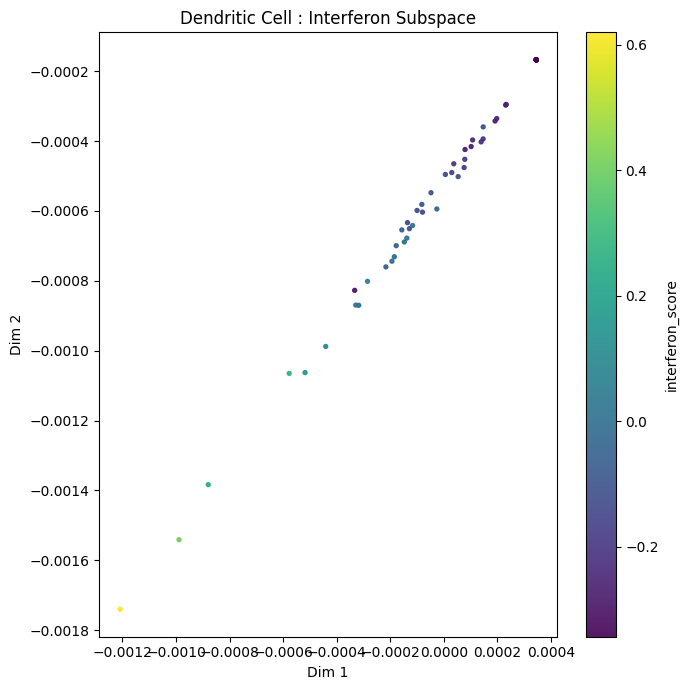

In [61]:
# Dendritic cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Interferon Subspace" 
)

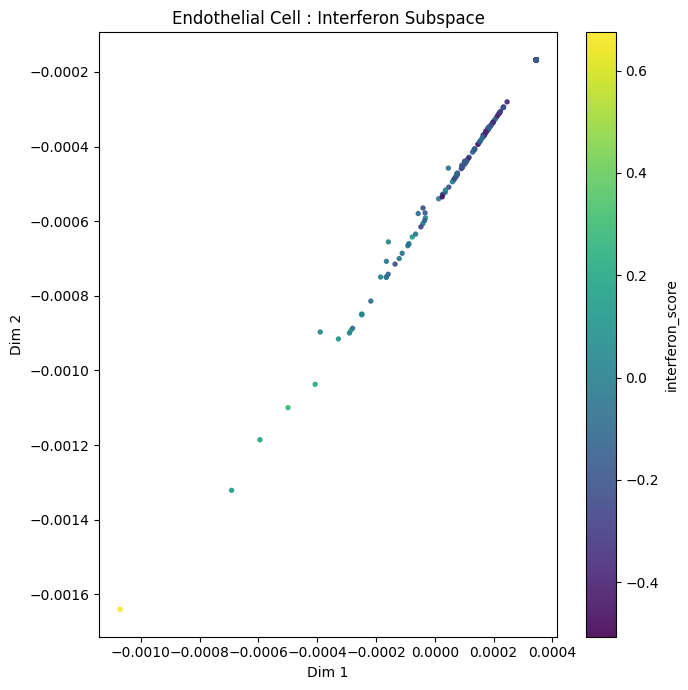

In [62]:
# Endothelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Interferon Subspace" 
)

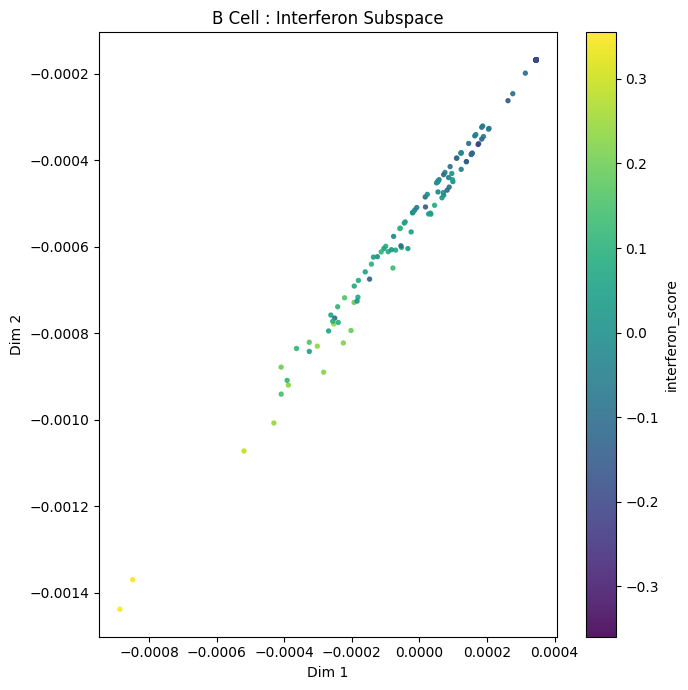

In [63]:
# B cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Interferon Subspace" 
)

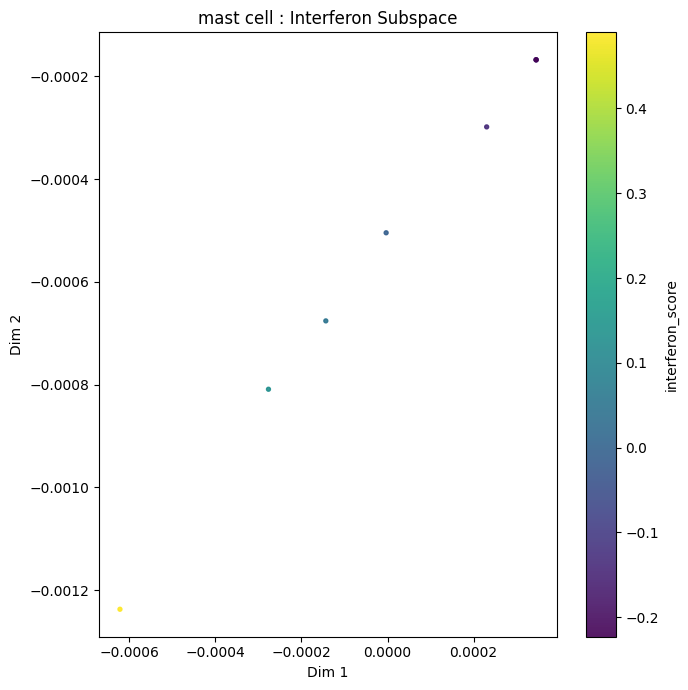

In [64]:
# mast cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Interferon Subspace" 
)

#### Pairwise Plots - 2 Dissociation Experiments

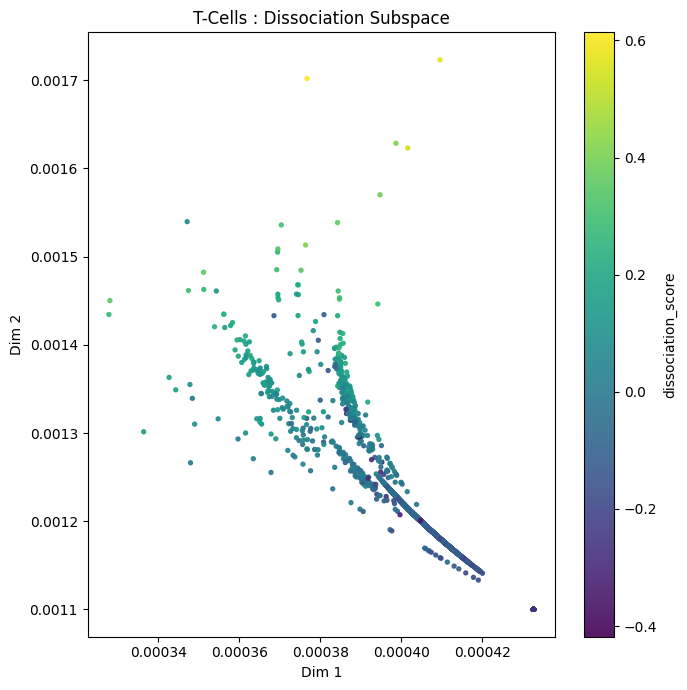

In [65]:
# T-cells
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Dissociation Subspace" 
)

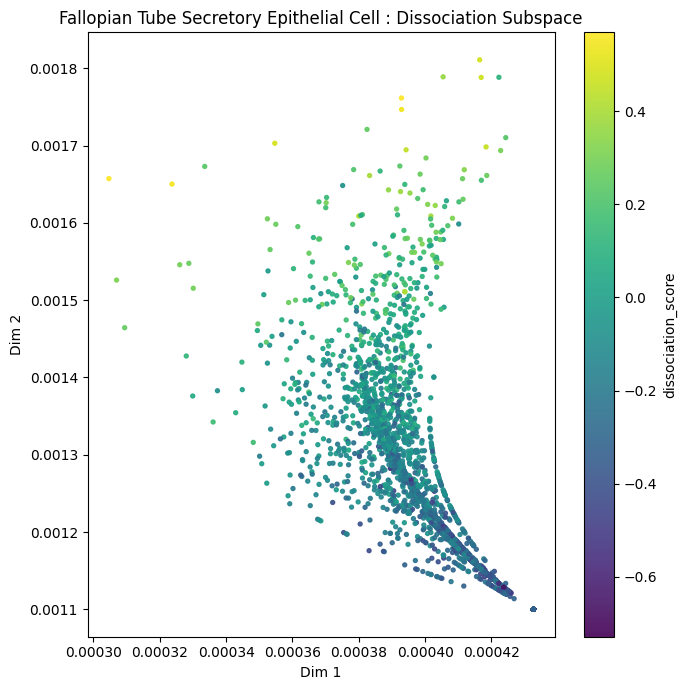

In [66]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Dissociation Subspace" 
)

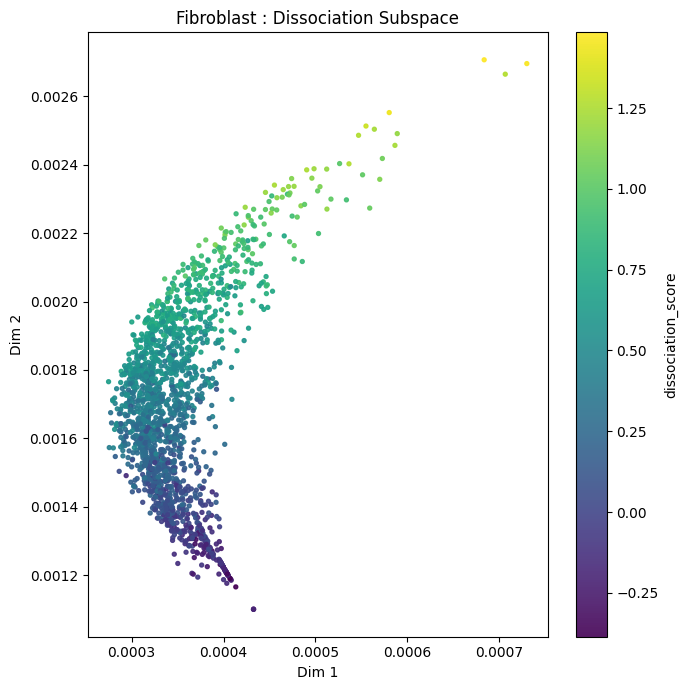

In [67]:
# Fibroblast 
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'
visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Dissociation Subspace" 
)

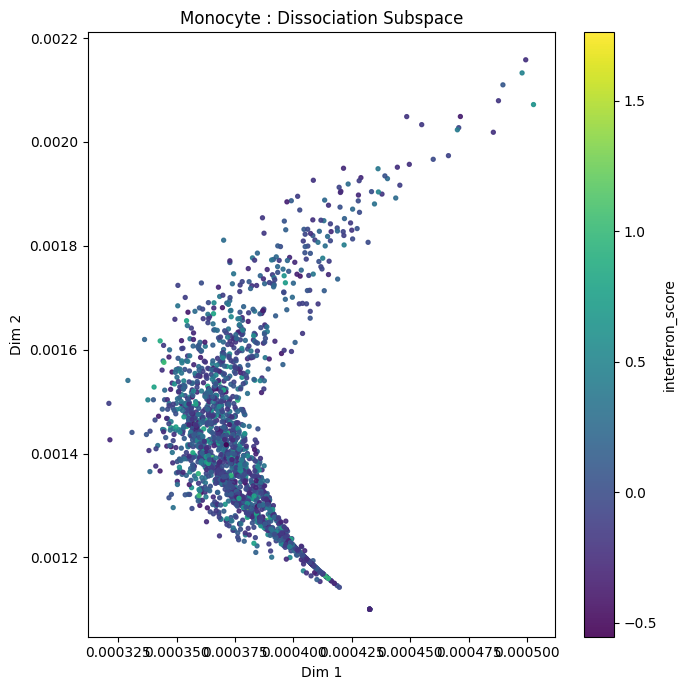

In [68]:
# Monocyte
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Dissociation Subspace" 
)

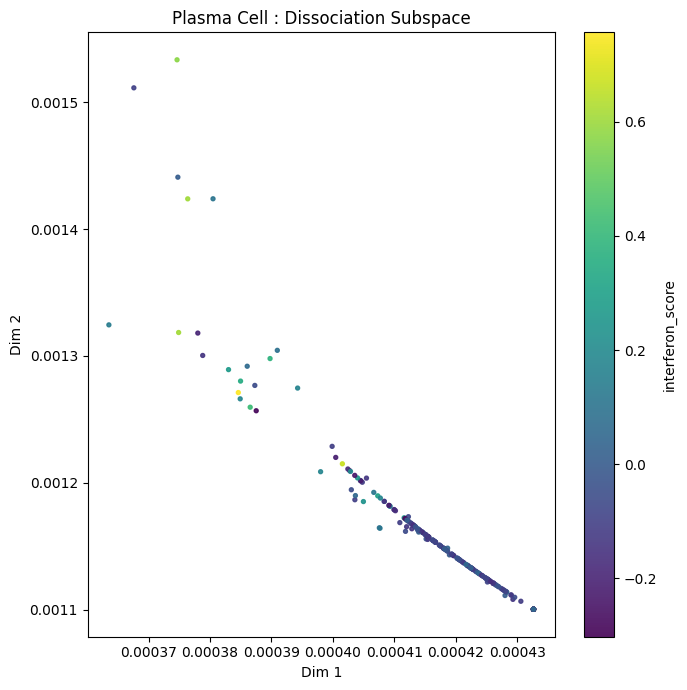

In [69]:
# Plasma cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Dissociation Subspace" 
)

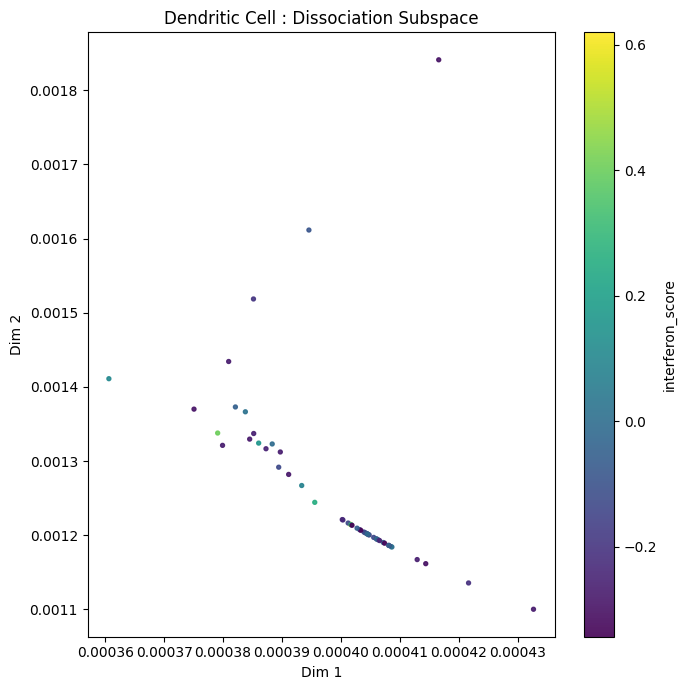

In [70]:
# Dendritic cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Dissociation Subspace" 
)

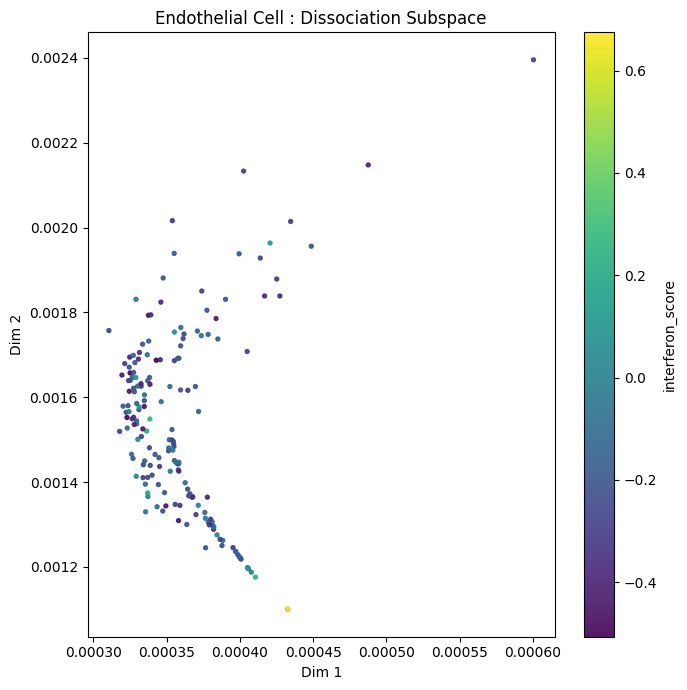

In [71]:
# Endothelial cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Dissociation Subspace" 
)

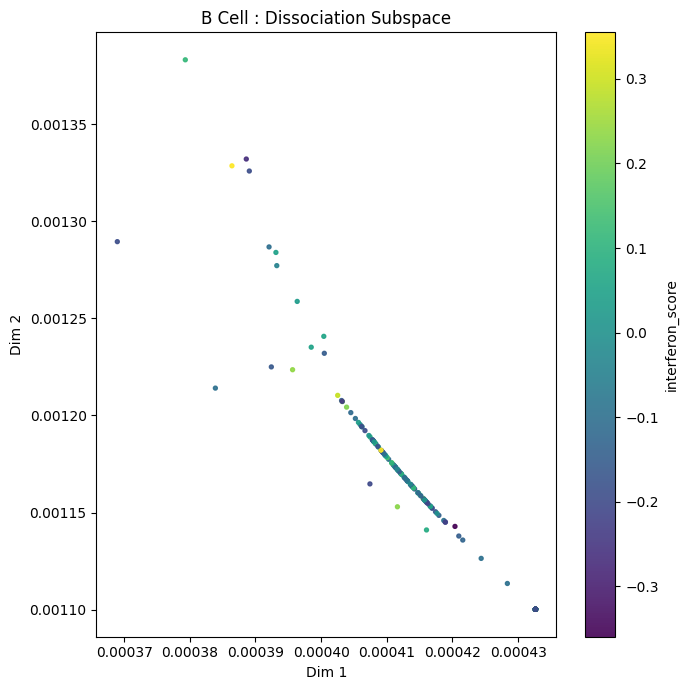

In [72]:
# B cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Dissociation Subspace" 
)

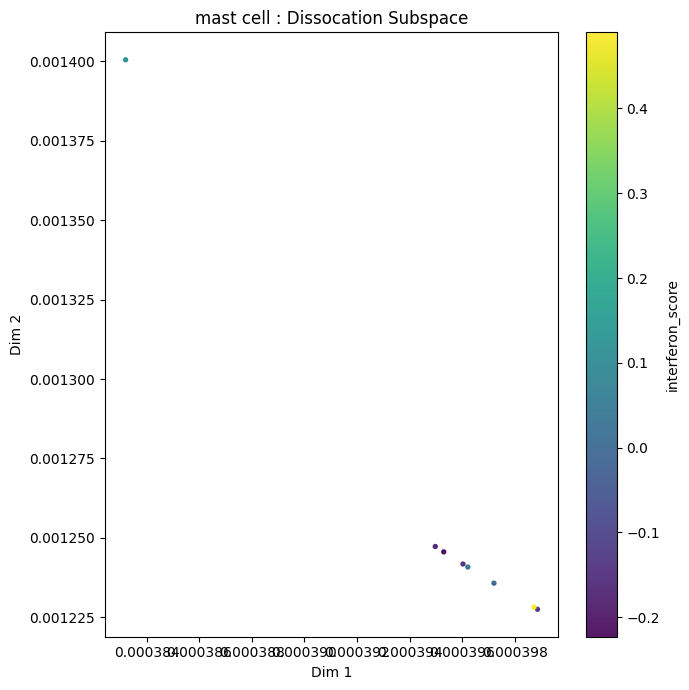

In [73]:
# mast cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Dissocation Subspace" 
)

In [67]:
adata.obs["cell_type"].unique()

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                                                   T cell
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC              fallopian tube secretory epithelial cell
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA                                        T cell
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG                                  fibroblast
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG                                       T cell
                                                                                    ...                   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA                                      T cell
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT                                    fibroblast
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                   fallopian tube secretory epithelial cell
SPECTRUM-OV-009_S1_CD45P_RIGH

In [65]:
adata.obsm[embeddings_key]

array([[-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       ...,
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896]], shape=(10199, 10))

In [66]:
adata.obs[desired_obs]

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                -0.066753
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC             -0.060493
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA     -0.054439
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG   -0.080584
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG    -0.061362
                                                                    ...   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA    0.003020
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT     -0.224252
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                  -0.173922
SPECTRUM-OV-009_S1_CD45P_RIGHT_OVARY_TCACTCGCATCTCGTC            -0.052288
SPECTRUM-OV-071_S1_CD45P_LEFT_OVARY_AGGCATTTCCGACAGC              0.029909
Name: G2M.Score, Length: 10199, dtype: float32

**QUESTIONS**
- Is using "everything else" to capture cell type really the best technique to use?
- Why does CellUntangler use the first latent subspace to reconstruct the genes that don't belong in the gene mask (when only the first latent subspace is used for reconstructing those genes that belong in the first gene mask)?
  A decision I need to might need to make (if the code doesn't already think about this and implement it)
  - Should all earlier subspaces contribute to the reconstruction of subsets of genes corresponding to later subspaces? Or, should only the last subset of genes (presumably corresponding to the largest number of genes) be reconstructed using the all latent subspaces up to the last subspace?
  - A sub-question: what guarantees disentanglement in models like CellUntangler?
  - Hmmm, if we stopped the gradient for all earlier subspaces when training later subspaces, would this ensure that earlier subspaces never "tweak" their parameters to get better at reconstructing a subset of genes unrelated to the subset of genes they should best reconstruct? 

What owu

**Worklist** 
- (HSSOC) Getting stuck on 2+ subspace CellUntangler (Get blocked on nuances of stopping gradients) 
- (Liver) Getting stuck on better benchmarking
- (Liver) Getting started on biological analysis of different dimensions + generating pairwise plots of disentangled dimensions 

**Ideas** 
- Might be useful to mix HGSOC dataset with non-cancerous cells to see how well the cell dissociation signal is captured in a particular latent space

**Deep Dives**
- What makes a "rotated" hyperbolic component "rotated"?
- How to visualize learnable curvatures in latent spaces? 